# Semantic Search

This notebook shows hot to make use of pre-trained Transformer models for document embeddings.
These models are trained using *supervised* or *unsupervised* approaches to encode text at sentence-level, paragraph-level or even entire document-level.
They can be applied to many different tasks
- Semantic similarity
- Paraphrase detection
- Natural Langage Inference
- Question Answering
- Information retreival
- Clustering

Most of the material is based on the tuorial and examples on [Sentence Transformers](https://www.sbert.net/docs/)

**Optional for Colab users**

Before starting, we can set up the connection with the Google Dive storage, to keep there our documents.
Just execute the following passages:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Make sure that the variable path contains the correct sequence of folders separate by a `'/'` to get to your lecture files

In [ ]:
import os

path = 'Colab Notebooks/NLP-tutorials-2026'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()

## Prepare environment

In [ ]:
!pip install -U sentence-transformers
!pip install datasets
!pip install hnswlib

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

## From BERT to Semantic Embedding


You remember BERT model?

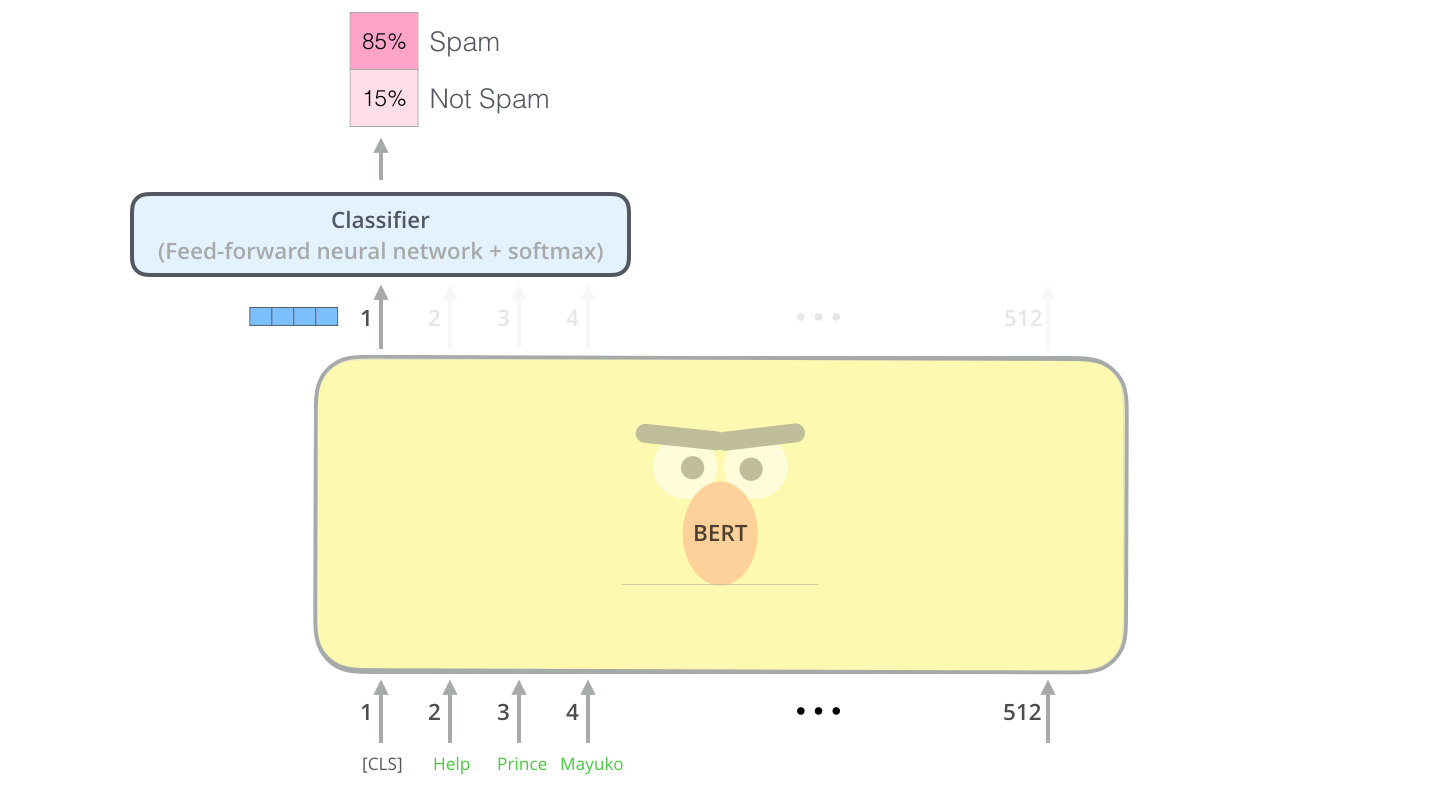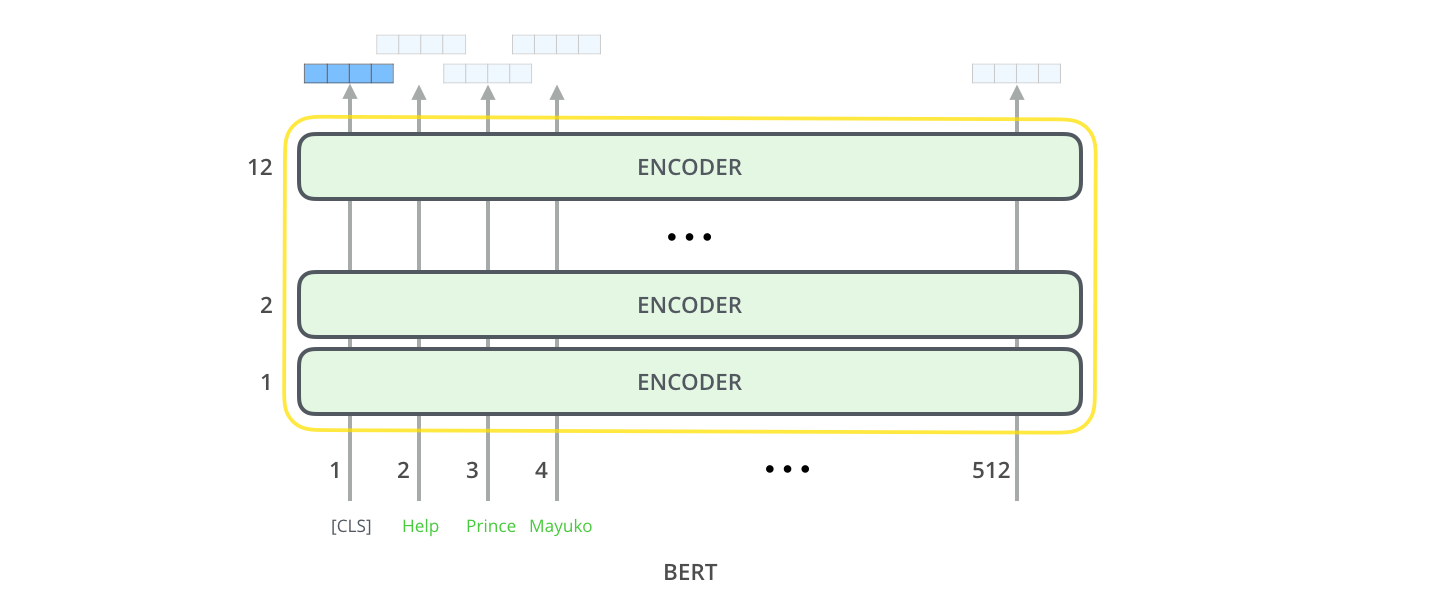


### **How can we extract a semantic embedding from this model?**

### Any idea?

We previously used the **embedding (latent vector) from the [CLS] token**, so potentially we could use it again as a semantic representation of the sentence right? Well, turns out that performances were pretty low and so it was not well suited for representing semantic meaning of a sentence, as eplained in this famous work ([SBERT](https://arxiv.org/pdf/1908.10084))

### Can you tell why is the case?
HINT: Remember the MLM task?

## Sentence transformer models

Today we are going to use an extension of the [Transformers library](https://huggingface.co/docs/transformers/index) designed for sentence level analysis (and more): [Sentece Transfomers](https://www.sbert.net) (origianlly known as SenteceBERT or [SBERT](https://arxiv.org/pdf/1908.10084) )

SBERT models are basically simple plain BERT models, but with a particular head and a particular training procedure, aimed at optimize the creation of a meaningful semantic embedding.

<div>
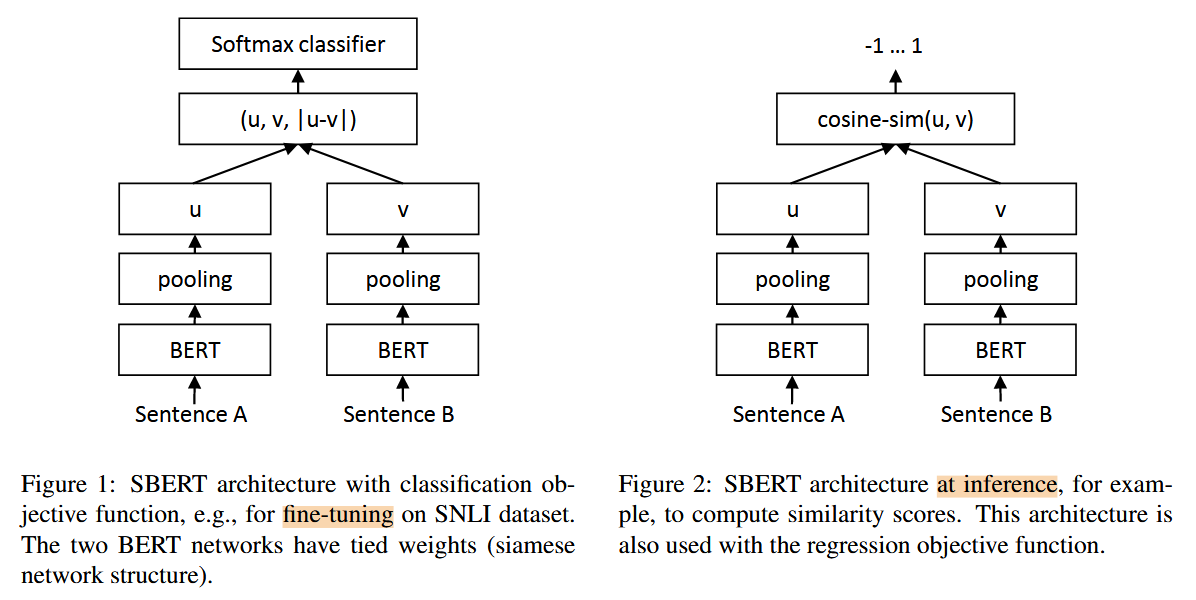
</div>

First of all we need to import the sentence transformer and some utilities.

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

### Embedding text

Let's create an instance of sentence embedding model based on BERT.
Here you have a list of the available pre-trained models for sentence embedding https://www.sbert.net/docs/pretrained_models.html.

In [ ]:
from google.colab import userdata
import os

os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')

In [ ]:
model = SentenceTransformer('all-mpnet-base-v2')

You may see some strange logs while loading the model like:


```
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  |
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  |

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
```


As discussed in [here](https://discuss.huggingface.co/t/embeddings-position-ids-unexpected-warning-started-showing/173102), this is due to recent updates of HugginFace/Pytorch libraries internal loading procedures. If the only `UNEXPECTED` checkpoint is in `embedding.position_ids`, this warning is **safe to be ignored**.

Let's define a corpus of a few sentences to try out the embedding model

In [ ]:
corpus = [
    'A man is eating food.',
    'A man is eating a piece of bread.',
    'The girl is carrying a baby.',
    'A man is riding a horse.',
    'A woman is playing violin.',
    'Two men pushed carts through the woods.',
    'A man is riding a white horse on an enclosed ground.',
    'A monkey is playing drums.',
    'A cheetah is running behind its prey.'
]

We can embed the text in batches with the `encode()` method

In [ ]:
corpus_embeddings = model.encode(corpus, convert_to_tensor=True)
corpus_embeddings.size()

Let's give a look at one of the embeddings

In [ ]:
corpus_embeddings[0]

### Cosine similarity between embeddings

We can compute the similarity of embedding pairs in our corpus. We first create a matrix by stacking vertically (`torch.vstack()`) the similarity (`util.cos_sim()`) between each embedding and all the others.

In [ ]:
similarity_matrix = torch.vstack(
    [util.cos_sim(embedding, corpus_embeddings)[0] for embedding in corpus_embeddings]
)
similarity_matrix.size()

And show the similarities in a matrix.
Here the brighter the colour the higher the similarity.

In [ ]:
plt.matshow(similarity_matrix.cpu().numpy())
plt.xlabel('Sentence index')
plt.ylabel('Sentence index')
plt.colorbar()
plt.tight_layout()

What do you think of the results? These are the sentences we used

In [ ]:
for idx, sentence in enumerate(corpus):
    print(f"{idx}:\t\"{sentence}\"")

On the diagonal we have a perfect match since we are computing the similarity between a piece of text and itself.

### Visualising the embedding space

Ok, looking at lists of numbers is not very useful.
We can try to do some visualisation here.

Let's start by showing the embeddings we computed early.

In [ ]:
fig = plt.figure(figsize=(10, 8))
plt.matshow(corpus_embeddings.cpu().numpy(), aspect='auto')
plt.xlabel('Feature');
plt.ylabel('Sentence');

Yeah, that's not very informative.

Now let's load a bigger data set so we can learn one of those fancy down-projection like TSNE to visualise the embeddings in a 2D or 3D space.
We can use the sentences in the [SNLI](https://arxiv.org/abs/1508.05326) data set, it is avaialble through the HuggingFace Datasets package (https://huggingface.co/datasets/snli).

In [ ]:
import datasets

snli = datasets.load_dataset('snli', split='train')
snli[0]

This data set is used for a task called "Natural Language Inference" (NLI), the task is to recognise the relationship between two sentences:
- Neutral
- Entailment
- Contradiction

We are just interested in the sentences, so we can drop the structure of the data set.

In [ ]:
sentences = list(set(sample[key] for sample in snli for key in ['premise', 'hypothesis']))
len(sentences)

In [ ]:
sentences[0]

We can embed a subset of these sentences

In [ ]:
corpus_embeddings = model.encode(sentences[::300], convert_to_tensor=True).cpu().numpy()
corpus_embeddings.shape

Now let's use TSNE to learn a low dimensional representation...

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, n_iter=500)
tsne_embedding = tsne.fit_transform(corpus_embeddings)

... and plot it in three dimensions

In [ ]:
!pip install plotly

In [ ]:
import numpy as np
import plotly.express as px

x, y, z = np.transpose(tsne_embedding)

fig = px.scatter_3d(x=x, y=y, z=z)
fig.update_traces(marker=dict(size=3,line=dict(width=2)))
fig.show()

Now let's select randomly a few sentences to display

In [ ]:
# Select ranomly the sentences
embed_idxs = np.random.choice(np.arange(len(tsne_embedding)), 10)
sent_idxs = np.arange(0, len(sentences), 300)[embed_idxs]

# Plot the selected sentences
fig = px.scatter_3d(x=x[embed_idxs], y=y[embed_idxs], z=z[embed_idxs], text=embed_idxs)
fig.update_traces(marker=dict(size=3,line=dict(width=2)))
fig.show()

Let's give a look at the text of the selected sentences

In [ ]:
for e_idx, s_idx in zip(embed_idxs, sent_idxs):
    print(f"{e_idx:6d}:\t\"{sentences[s_idx]}\"")

### Multi-lingual models

We have models working with multiple languages, this means we can compute also cross-language similarity

In [ ]:
multilingual_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

Let's pick a sentence and translate it in multiple languages

In [ ]:
# multilingual_corpus = [
#     "Where is the library?",
#     "¿Donde está la biblioteca?",
#     "Dov'è la biblioteca?"
# ]
multilingual_corpus = [
    "I am Mark Carman and I'm from Australia... Mate!",
    "Sono Mark Carman e vengo dall'Australia... Amico!",
    "Soy Mark Carman y soy de Australia... Compañero!",
    "Ich bin Mark Carman und ich komme aus Australien... Kumpel!",
    "L'arancione è il mio colore preferito!"
]

Now let's compute the similarity between translation pairs

In [ ]:
for idx, s1 in enumerate(multilingual_corpus):
    for s2 in multilingual_corpus[idx + 1:]:
        s1_embeddings = model.encode(s1, convert_to_tensor=True)
        s2_embeddings = model.encode(s2, convert_to_tensor=True)

        print(f"Sentence 1: \"{s1}\"")
        print(f"Sentence 2: \"{s2}\"")
        print("---------------------------------------------------------------")
        print(f"Cosine similarity: {util.cos_sim(s1_embeddings, s2_embeddings)[0].item():.2f}")
        print("\n\n\n\n")

## Semantic search

We have just seen how to extract contextual embeddings of sentences, so we can use these embeddings to do **semantic search**!




But, is the previous method the only possible way in which we can compute an embedding of a sentence?
The answer is no!
Right now, starting from the embedding created with SBERT we can:
- Use the **cosine similarity** between the embeddings of documents and queries to search through a collection of documents exploting semantics (meaning) rather than syntax.
This approach is called **"Bi-Encoder"**.

Alternatively, instead of encoding separately the document and the query, we can **train a model** that works on both at the same time and **predicts** directly **similairty** score. This approach is called **"Cross-Encoder"**

### Computing document-query similarity


#### **Bi-Encoder**

We can use an encoder model like BERT to extract the emebeddings of two sentences seprately and compare them though cosine similarity. Just what

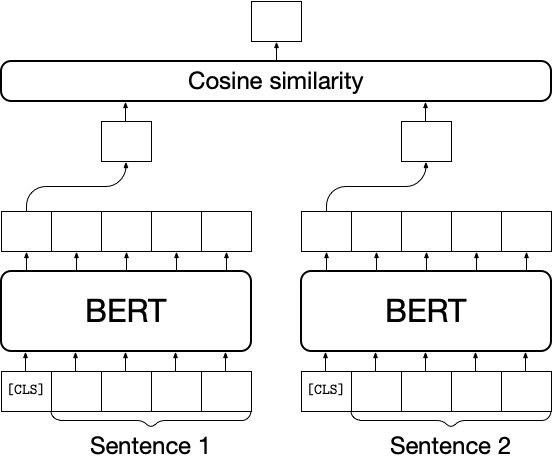

Note that since sentences are encoded separately one from the other, we can pre-compute the embeddings forming some sort of indexed data base and exploit the pre computed embeddings for a later search.

Let's get back at the examples sentence from before and embed them

In [ ]:
docs = [
    'A man is eating food.',
    'A man is eating a piece of bread.',
    'The girl is carrying a baby.',
    'A man is riding a horse.',
    'A woman is playing violin.',
    'Two men pushed carts through the woods.',
    'A man is riding a white horse on an enclosed ground.',
    'A monkey is playing drums.',
    'A cheetah is running behind its prey.'
]
docs_embeddings = model.encode(docs, convert_to_tensor=True, device='cuda')

Now we can create a set of queries for semantic similarity

In [ ]:
queries = [
    'A man is eating pasta.',
    'Someone in a gorilla costume is playing a set of drums.',
    'A cheetah chases prey on across a field.'
]

Let's find the closest 5 sentences of the corpus for each query sentence based on cosine similarity

In [ ]:
# Let's set the maximum number of matches to retrieve
top_k = min(5, len(corpus))
# Iterate over queries
for query in queries:
    # Embed query
    query_embedding = model.encode(query, convert_to_tensor=True)
    # Use cosine-similarity and torch.topk to find the highest 5 scores
    cos_scores = util.cos_sim(query_embedding, docs_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    # Print the result
    print(f"Query: \"{query}\"")
    print("Top 5 most similar sentences in corpus:")
    print("---------------------------------------")
    for score, idx in zip(top_results[0], top_results[1]):
        print(f"Score: {score:.2f} - Document: \"{corpus[idx]}\"")
    print("\n\n\n\n")

Alternatively, we can use the built in function for semantic search that computes automatically all the query-document similarity pairs

In [ ]:
query_embeddings = model.encode(queries, convert_to_tensor=True)

util.semantic_search(query_embeddings, docs_embeddings, score_function=util.cos_sim)

#### Speed up cosine similarity

We can speed-up the process by pre-nomalising the embeddings and compute directly the dot-product instead of cosine similarity.

In [ ]:
normlaised_docs_embeddings = util.normalize_embeddings(model.encode(docs, convert_to_tensor=True))
normalised_query_embeddings = util.normalize_embeddings(model.encode(queries, convert_to_tensor=True))

In [ ]:
hits = util.semantic_search(normalised_query_embeddings, normlaised_docs_embeddings, score_function=util.dot_score)
hits

#### **Cross-encoder**

Cross encoder models work by encoding together the sentences in a pair or a document-query pair.

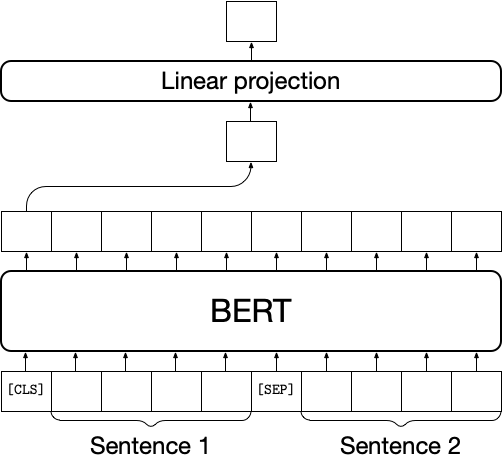

Differently from the previous models that can be trained either with a supervised approach or with an unsupervised approach, in this case they only work if trained for some supervised target like classification (e.g., paraphrase detection) or regression (e.g., sentence similarity).

Let's load a cross-encoder model

In [ ]:
from sentence_transformers import CrossEncoder

model = CrossEncoder('cross-encoder/stsb-distilroberta-base')

Let's use this model to compute the similarity between the queries and the documents

In [ ]:
import numpy as np

# Iterate over queries
for query in queries:
    # Prepare model inputs
    model_inputs = [[query, doc] for doc in docs]
    # Predict similarity score
    scores = model.predict(model_inputs)
    # Print the result
    print(f"Query: \"{query}\"")
    print("---------------------------------------")
    for idx in np.argsort(-scores):
        print(f"Score: {scores[idx]:.4f} - Document: \"{corpus[idx]}\"")
    print("\n\n\n\n")

### Question answering pipeline

Ok this is cool, but what can we do when we have a large data set and complex applications like question answering?
Let's try out!

Let's start by loading a sentence embedding model and a cross encoder model

In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder, util

semb_model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')
xenc_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

#### Prepare data

We can load a reduced copy of Wikipedia ([Simple Wikipedia](https://simple.wikipedia.org/wiki/Main_Page)).



Let's start by downloading the data set if it is not avaialble

In [ ]:
import os

wikipedia_filepath = 'simplewiki-2020-11-01.jsonl.gz'
if not os.path.exists(wikipedia_filepath):
    util.http_get('http://sbert.net/datasets/simplewiki-2020-11-01.jsonl.gz', wikipedia_filepath)

Now let's load the first paragraph of each document

In [ ]:
import json
import gzip

passages = []
# Open the file with the dump of Simple Wikipedia
with gzip.open(wikipedia_filepath, 'rt', encoding='utf8') as f:
    # Iterate over the lines
    for line in f:
        # Parse the document using JSON
        data = json.loads(line.strip())
        # Add all paragraphs
        #passages.extend(data['paragraphs'])
        # Only add the first paragraph
        passages.append(data['paragraphs'][0])

print(f"Retreived {len(passages)} passages")

Now we can embed the retrieved passages using the sentence embedding model

In [ ]:
corpus_embeddings = semb_model.encode(passages, convert_to_tensor=True, show_progress_bar=True)

#### Approximated Nearest Neighbor search

When we use an embedding model with cosine similarity, we can pre-compute the embeddings in our data set and index them to speed-up the search.
There are techniques for Approximate Nearest Neighbor (ANN), which use clustering to index the embedding space and speed-up the search process.

Note that this is not applicable to cross-encoder models, which encode document and query together.

Sentence transformers support different libraries for ANN:
- [HNSWLIB](https://github.com/nmslib/hnswlib/)
- [Annoy](https://github.com/spotify/annoy)
- [FAISS](https://github.com/spotify/annoy)

Let's try indexing with **HNSWLIB** (yes yes I know, do or do not, there is not try...)

Import the HNSWLIB library and create and empty index

In [ ]:
import hnswlib

index = hnswlib.Index(space='cosine', dim=corpus_embeddings.size(1))

Now we can index our data. The index we compute can be saved and loaded, so we can check if it is already availabel and load it (this will save time)

In [ ]:
import os

# Define hnswlib index path
index_path = "./hnswlib.index"

# Load index if available
if os.path.exists(index_path):
    print("Loading index...")
    index.load_index(index_path)
# Else index data collection
else:
    # Initialise the index
    print("Start creating HNSWLIB index")
    index.init_index(max_elements=corpus_embeddings.size(0), ef_construction=400, M=64)
    #  Compute the HNSWLIB index (it may take a while)
    index.add_items(corpus_embeddings.cpu(), list(range(len(corpus_embeddings))))
    # Save the index to a file for future loading
    print("Saving index to:", index_path)
    index.save_index(index_path)

Is it really faster to search? Let's see.

We can create a query

In [ ]:
query = "Why is it that the plural of finger is fingers and not hand?"
query_embedding = semb_model.encode(query, convert_to_tensor=True)

And measure the running time

In [ ]:
from datetime import datetime

# Search using index
t_start = datetime.now()
_ = index.knn_query(query_embedding.cpu(), k=128)
t_stop = datetime.now()
print(f"Search time with index: {t_stop - t_start}")

# Search without index
t_start = datetime.now()
_ = util.semantic_search(query_embedding, corpus_embeddings, score_function=util.cos_sim, top_k=128)
t_stop = datetime.now()
print(f"Search time without index: {t_stop - t_start}")

### Re-ranking

Cross-encoder models empirically yield better results, but are slow at inference.
Embedding models with cosine similarity, on the other side, are less precise, but are also faster at inference.

We can take advantage of both: We can do a first search with bi-encoder models and then re-rank the top-$k$ results with a cross-encoder.
We call this approach ***retrieve and re-rank***.

Let's use the ANN index we just computed and a cross encoder model to build a retrieval pipeline

Define a query

In [ ]:
query = "Which is the capital of the United States?"
query_embedding = semb_model.encode(query, convert_to_tensor=True)

Search using ANN index

In [ ]:
corpus_ids, distances = index.knn_query(query_embedding.cpu(), k=3)
scores = 1 - distances

print("Cosine similarity model search results")
print(f"Query: \"{query}\"")
print("---------------------------------------")
for idx, score in zip(corpus_ids[0], scores[0]):
    print(f"Score: {score:.4f}\nDocument: \"{passages[idx]}\"\n\n")

Let's add the re-ranking

In [ ]:
corpus_ids, _ = index.knn_query(query_embedding.cpu(), k=128)

model_inputs = [(query, passages[idx]) for idx in corpus_ids[0]]
cross_scores = xenc_model.predict(model_inputs)

print("Cross-encoder model re-ranking results")
print(f"Query: \"{query}\"")
print("---------------------------------------")
for idx in np.argsort(-cross_scores)[:3]:
    print(f"Score: {cross_scores[idx]:.4f}\nDocument: \"{passages[corpus_ids[0][idx]]}\"\n\n")

Try out other queries

In [ ]:
query = "What is the best orchestra in the world?"
query_embedding = semb_model.encode(query, convert_to_tensor=True)

corpus_ids, _ = index.knn_query(query_embedding.cpu(), k=128)

model_inputs = [(query, passages[idx]) for idx in corpus_ids[0]]
cross_scores = xenc_model.predict(model_inputs)

print("Cross-encoder model re-ranking results")
print(f"Query: \"{query}\"")
print("---------------------------------------")
for idx in np.argsort(-cross_scores)[:3]:
    print(f"Score: {cross_scores[idx]:.4f}\nDocument: \"{passages[corpus_ids[0][idx]]}\"\n\n")

In [ ]:
query = "Number countries Europe"
query_embedding = semb_model.encode(query, convert_to_tensor=True)

corpus_ids, _ = index.knn_query(query_embedding.cpu(), k=128)

model_inputs = [(query, passages[idx]) for idx in corpus_ids[0]]
cross_scores = xenc_model.predict(model_inputs)

print("Cross-encoder model re-ranking results")
print(f"Query: \"{query}\"")
print("---------------------------------------")
for idx in np.argsort(-cross_scores)[:3]:
    print(f"Score: {cross_scores[idx]:.4f}\nDocument: \"{passages[corpus_ids[0][idx]]}\"\n\n")

In [ ]:
query = "When did the cold war end?"
query_embedding = semb_model.encode(query, convert_to_tensor=True)

corpus_ids, _ = index.knn_query(query_embedding.cpu(), k=128)

model_inputs = [(query, passages[idx]) for idx in corpus_ids[0]]
cross_scores = xenc_model.predict(model_inputs)

print("Cross-encoder model re-ranking results")
print(f"Query: \"{query}\"")
print("---------------------------------------")
for idx in np.argsort(-cross_scores)[:3]:
    print(f"Score: {cross_scores[idx]:.4f}\nDocument: \"{passages[corpus_ids[0][idx]]}\"\n\n")

## Retrieval-based chatbots

During the lectures you have started getting familiar with *chabots* (open-domain conversational agents).

We can use these semantic search pipelines to build a retrieval-based chatbot.
It is a data-driven kind of chatbot that gets responses from a data set.

We can use the same retreive and re-rank pipeline from before, let's start by importing the models.


In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder, util

semb_model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')
xenc_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

We are going to use a slightly different appraoch.
1. First we are going to rank by similarity of the last user sentence and the sentences in out corpus (the initial matches).
2. Then we we are going to extract the response to the matches in our data set. Intuitively, semantic similarity gives us a sentence that is similar to the query one, so we want to get the responses to a possible match.
3. We are going to re-rank the user-message and retreived-response pairs

### Dialogue data

For this part we are going to use the [EmpatheticDialogues](https://arxiv.org/pdf/1811.00207.pdf) data set, again available via the HuggingFace datasets library

#### Load

Let's start by loading our data set.
For simplicity we are going to use only the validation set.

We will use [this](https://huggingface.co/datasets/brianist/empathetic_dialogues) version of the dataset, since the original one was quite old and due to a major update on traformers datasets library ([Release-4.0.0](https://newreleases.io/project/github/huggingface/datasets/release/4.0.0))

In [ ]:
from datasets import load_dataset

empdialogues = load_dataset("brianist/empathetic_dialogues", split="train")
empdialogues[:3]

Now we need to build all the message-response pairs.

We start by grouping together the utterances (turns) that belong to the same dialogue.
First we convert the data set to a Pandas DataFrame

In [ ]:
import pandas as pd

df = pd.DataFrame(empdialogues)
df

Now we can goup the samples and go through individual dialogues to build the pairs

In [ ]:
data_pairs = []
# Iterate over dialogues
for _, dialogue_df in df.groupby('conv_id', sort=False):
    # Extract utterances text
    uttrances = dialogue_df['utterance'].values
    # Iterarte over pairs
    for message, response in zip(uttrances[:-1], uttrances[1:]):
        # Add pair to collection
        data_pairs.append(
            {'message': message.replace('_comma_', ','), 'response': response.replace('_comma_', ',')}
        )

len(data_pairs)

#### Index

Now we can embed the messages in our data set

In [ ]:
corpus_embeddings = semb_model.encode([sample['message'] for sample in data_pairs], convert_to_tensor=True, show_progress_bar=True)

And we can build an ANN index to do a quick cosine similarity search

In [ ]:
import os
import hnswlib

# Create empty index
hnswlib_index = hnswlib.Index(space='cosine', dim=corpus_embeddings.size(1))

# Define hnswlib index path
index_path = "./emp_dialogue_hnswlib.index"

# Load index if available
if os.path.exists(index_path):
    print("Loading index...")
    hnswlib_index.load_index(index_path)
# Else index data collection
else:
    # Initialise the index
    print("Start creating HNSWLIB index")
    hnswlib_index.init_index(max_elements=corpus_embeddings.size(0), ef_construction=400, M=64)
    #  Compute the HNSWLIB index (it may take a while)
    hnswlib_index.add_items(corpus_embeddings.cpu(), list(range(len(corpus_embeddings))))
    # Save the index to a file for future loading
    print("Saving index to:", index_path)
    hnswlib_index.save_index(index_path)

### Search for response

We are going to search for a response in the following way:
1. Search for a similar message to the latest user input.
2. Retrieve response associated to the message.
2. Re-rank possible responses.

#### Retrieval function

Let's define a response function

In [ ]:
import numpy as np

def get_response(message, mes_resp_pairs, index, re_ranking_model=None, top_k=32):
    message_embedding = semb_model.encode(message, convert_to_tensor=True).cpu()

    corpus_ids, _ = index.knn_query(message_embedding, k=top_k)

    model_inputs = [(message, mes_resp_pairs[idx]['response']) for idx in corpus_ids[0]]
    cross_scores = xenc_model.predict(model_inputs)

    idx = np.argsort(-cross_scores)[0]

    return mes_resp_pairs[corpus_ids[0][idx]]['response']

Note that the use of re-ranking is optional (you can pass a none `re_ranking_model`) and the top results to re-score are configurable.
You can play a bit with these hyperaparameters to see how responses change.

Let's try out the retreival function

In [ ]:
chatbot_response = get_response(
    "I like going out with my puppies.", data_pairs, hnswlib_index, re_ranking_model=xenc_model
)
chatbot_response

#### Conversation loop

Let's try chatting with our retreival system

In [ ]:
# Initialise dialogue history
dialogue_history = ["Hello, how are you?"]

# Start chatting
print("Press [Ctrl-C] to stop\n\n\n\n")
print(f"Chatbot: {dialogue_history[0]}")
# Keep talking until stop
running = True
while running:
    try:
        # Read user message
        user_message = input("User: ")
        # Append message to dialogue history
        dialogue_history.append(user_message)
        # Search for a chatbot response
        chatbot_response = get_response(
            user_message, data_pairs, hnswlib_index, re_ranking_model=xenc_model
        )
        # Append chatbot response to dialogue history
        dialogue_history.append(chatbot_response)
        # Print chatbot response
        print(f"Chatbot: {chatbot_response}")
    except KeyboardInterrupt:
        running = False

## [Supplement material] Comparisons of different retrievals


Now we will see how we can combine all the retrival techniques we have seen so far to build the best performing retrieval system.

In [ ]:
!pip install beir rank_bm25 faiss-cpu hnswlib ir_measures

### Load Dataset

We will use BEIR package to download a retrieval dataset with scientific claims verification. It contains documents that we are going to store in vector base, and a collection of queries with ground truth information of relevant documents.

BEIR: https://github.com/beir-cellar/beir

Scifact: https://github.com/allenai/scifact

In [ ]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader

dataset = "scifact"
url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{}.zip".format(dataset)
data_path = util.download_and_unzip(url, "datasets")

corpus, queries, qrels = GenericDataLoader(data_folder=data_path).load(split="test")
print("Number of documents: ", len(corpus))
print("Number of queries: ", len(queries))
print("Number of true retrievals: ", len(qrels))

Let's have a look at one query and associated documents

In [ ]:
query_id = '597'
query = queries[query_id]
print("Query: ", queries[query_id])
qrels[query_id]

In [ ]:
ref_doc_ids = list(qrels[query_id].keys())
ref_doc_ids[1], corpus[ref_doc_ids[1]]

Create list of documents by concatenating the title and body text for each document in the corpus.  

In [ ]:
corpus_ids, corpus_docs = list(corpus.keys()), list(corpus.values())
corpus_docs = [doc['title'] + '\n' + doc['text'] for doc in corpus_docs]
query_ids, query_texts = list(queries.keys()), list(queries.values())
top_k = 5

### Retrieval: one query

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np
import faiss
import hnswlib
import time
from sentence_transformers import SentenceTransformer, CrossEncoder, util

Timer object will help to measure code execution time

In [ ]:
class Timer:
    def __init__(self, name):
        self.name = name
        self.start = None

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        elapsed = time.perf_counter() - self.start
        print(f"{self.name} time is {elapsed :.0f}s {elapsed * 1000 % 1000 : .3f}ms")


Prepare bi-encoder model for retrieval and cross-encoder model for re-ranking, and define embedding functions. For sparse retrieval we split the text into words by spaces.

In [ ]:
bi_enc = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')
x_enc = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def embed_sparse(docs):
    return list(map(lambda text: text.split(" "), docs))

def embed_dense(encoder, docs):
    return encoder.encode(docs, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)

### Sparse retrieval

Implement sparse retrieval. We will use BM25 algorithm that relies on exact word matching and term frequencies.

https://pypi.org/project/rank-bm25/

To create sparse index, we need to process documents into words and initialize the BM25 retriever. Then let's perform sparse search of `top_k = 5` documents for one query, measure time and compare to real relevant documents.

In [ ]:
top_k = 5

# split text into words for sparse retrieval
doc_words = embed_sparse(corpus_docs)

In [ ]:
# create BM25 retriever
bm25 = BM25Okapi(doc_words)
bm25

# search
with Timer("Sparse Search"):
    query_words = embed_sparse([query])[0]
    scores = bm25.get_scores(query_words)
    doc_inds = np.argsort(-scores)[:top_k]

# get most similar document ids
doc_ids = [corpus_ids[int(ind)] for ind in doc_inds]
print('Best match document ids: ', doc_ids)
print('Reference document ids: ', ref_doc_ids)

2 retrieved documents `12779444` and `25742130` out of 5 retrieved match referenced documents.

### Approximated Nearest Neighbor search

Now let's compare different approaches

### Dense FAISS Retrieval

Faiss is a library for efficient similarity search and clustering of dense vectors developed by Facebook.

Python Package: https://pypi.org/project/faiss-cpu/


Documentation: https://faiss.ai/index.html

Flat Index: https://faiss.ai/cpp_api/struct/structfaiss_1_1IndexFlatIP.html

Let's create document embeddings and populate faiss index. Then perform dense search for one query and analyze as we did for sparse retrieval.

In [ ]:
# create dense embeddings
doc_embeddings = embed_dense(bi_enc, corpus_docs)
dim = doc_embeddings.shape[1]
doc_embeddings.shape

In [ ]:
# create index
index_faiss = faiss.IndexFlatIP(dim)
index_faiss.add(doc_embeddings)

# search
with Timer("FAISS Search"):
    query_embedding = embed_dense(bi_enc, [query])[:1]
    doc_scores, doc_inds = index_faiss.search(query_embedding, top_k)

# print
doc_ids = [corpus_ids[int(ind)] for ind in doc_inds[0]]
print('FAISS document ids: ', doc_ids)
print('Reference document ids: ', ref_doc_ids)

In this case all three referenced documents were retrieved, although some extra documents appear to have higher similarity score (appear earlier in  a retrieved list).

### Dense HNSW Retrieval

<div>
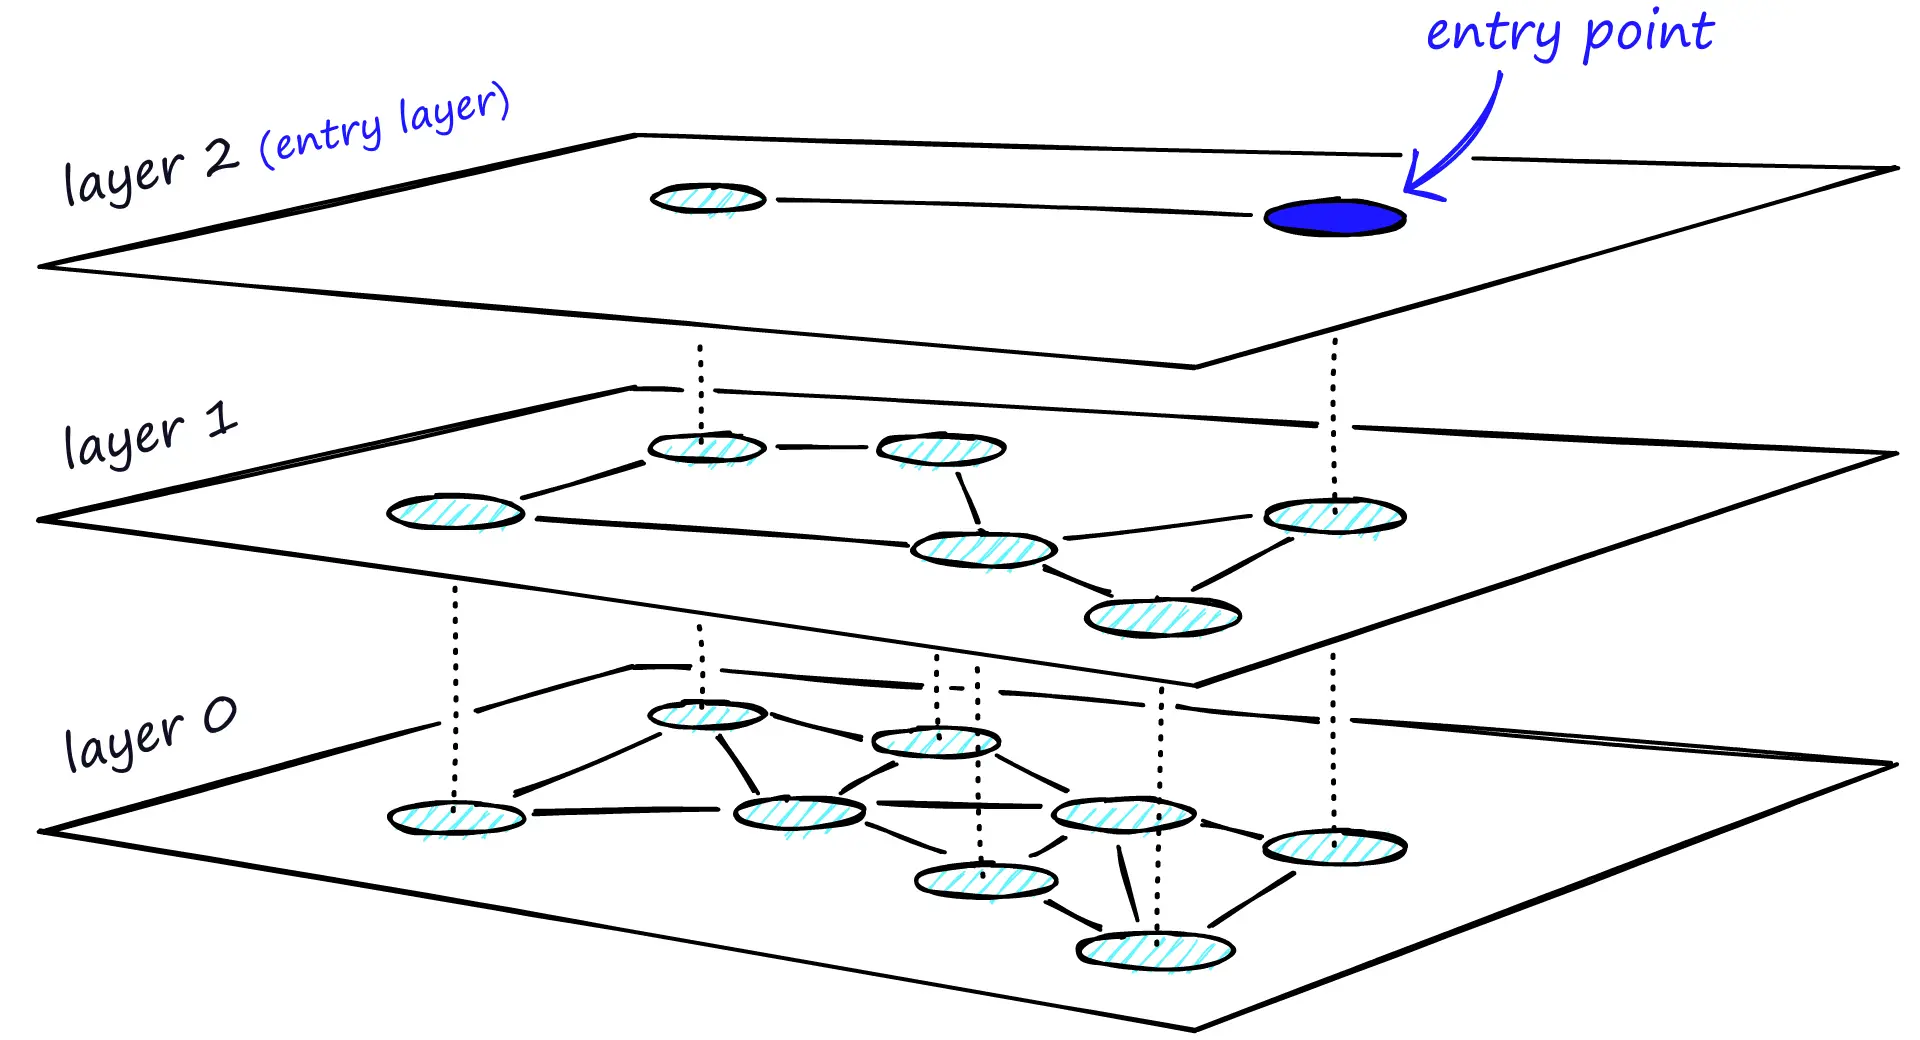
</div>

Hierarchical Navigable Small World (HNSW) graphs are among the top-performing indexes for vector similarity search. The HNSW graph offers an approximate k-nearest neighbor search which scales logarithmically even in high-dimensional data.

Let's index documents and analyze dense search for one query as before:

In [ ]:
# create index
index_hnsw = hnswlib.Index(space='cosine', dim=dim)
index_hnsw.init_index(max_elements=len(corpus_docs), ef_construction=200, M=32)
index_hnsw.add_items(doc_embeddings, list(range(len(corpus_ids))))

# search
with Timer("HNSW Search"):
    query_embedding = embed_dense(bi_enc, [query])[:1]
    doc_inds, doc_scores = index_hnsw.knn_query(query_embedding, k=top_k)

# print
doc_ids = [corpus_ids[int(ind)] for ind in doc_inds[0]]
print('HNSW document ids: ', doc_ids)
print('Reference document ids: ', ref_doc_ids)

1. **HNSW takes less time than FAISS** to retrieve 5 documents from ~5K dense vector store.
2. Retrieved documents are exactly the same as in FAISS search with the same ranking order.

### Dense Retrieval with Re-ranking

Let's now see how the retrieval and reranking approach works in this case. As before, we will use the already computed index to build the retrieval system (dense) and than re-rank with a cross encoder model.

In [ ]:
# dense search
query_embedding = embed_dense(bi_enc, [query])[:1]
doc_inds, _ = index_hnsw.knn_query(query_embedding, k=top_k)
doc_ids = [corpus_ids[int(ind)] for ind in doc_inds[0]]

# re-ranking of top-k with cross-encoder
text_pairs = [(query, corpus_docs[int(doc_ind)]) for doc_ind in doc_inds[0]]
scores = x_enc.predict(text_pairs)
scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
idxs = np.argsort(-scores)
doc_ids = [doc_ids[idx] for idx in idxs]
print('Re-ranked document ids: ', doc_ids)
print('Reference document ids: ', ref_doc_ids)

In this case all reference documents appear with highest ranks among all retrieved documents! Cross-encoder re-ranking helped to assign better relevance scores to retrieved documents and improve the order.

### Retrieval evalualion on full dataset

Now let's evaluate retrieval approaches on the full dataset using ground truth data. We will use `ir_measures` library.

https://ir-measur.es/en/latest/

In [ ]:
from ir_measures import nDCG, Recall, Precision, calc_aggregate

### Sparse, Dense, Dense retrieve and re-rank

Let's implement sparse, dense, and retrieve-and-rerank methods as we did before. Each function takes `query` and `top_k` as parameters,and outputs `run` dictionary with retrieved documents: `{doc_id: score}`. These functions rely on sparse and dense retrievers that are already defined globally.

In [ ]:
def sparse_search(query, top_k):
    query_words = embed_sparse([query])[0]

    # get similarity scores
    scores = bm25.get_scores(query_words)
    doc_inds = np.argsort(-scores)[:top_k]

    # format to run
    scores = [scores[ind] for ind in doc_inds]
    if np.max(scores) != np.min(scores):
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
    scores = list(map(float, scores))
    doc_ids = [corpus_ids[int(ind)] for ind in doc_inds]
    run = {doc_id: score for doc_id, score in zip(doc_ids, scores)}
    return run

def dense_search(query, top_k):
    # get similarity scores
    query_embedding = embed_dense(bi_enc, [query])[:1]
    doc_inds, scores = index_hnsw.knn_query(query_embedding, k=top_k)

    # format to run
    run = {corpus_ids[int(ind)]: float(s) for ind, s in zip(doc_inds[0], scores[0])}
    return run

def dense_search_rerank(query, top_k):
    # get similarity scores
    query_embedding = embed_dense(bi_enc, [query])[:1]
    doc_inds, _ = index_hnsw.knn_query(query_embedding, k=top_k)
    doc_ids = [corpus_ids[int(ind)] for ind in doc_inds[0]]

    # re-ranking of top-k with cross-encoder
    text_pairs = [(query, corpus_docs[int(doc_ind)]) for doc_ind in doc_inds[0]]
    scores = x_enc.predict(text_pairs)

    # format to run
    if np.max(scores) != np.min(scores):
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
    idxs = np.argsort(-scores)
    run = {doc_ids[idx]: float(scores[idx]) for idx in idxs}
    return run

Implement `search` and `evaluate` functions, that perform information retrieval and evaluation on full dataset. We will use `nDCG`, `Recall` and `Precision` metrics to assess retrieval for `top_k = 15`.

https://ir-measur.es/en/latest/measures.html

In [ ]:
def search(queries, search_func, top_k):
    runs = {}
    for query_id in queries:
        query_i = queries[query_id]
        runs[query_id] = search_func(query_i, top_k)
    return runs

def evaluate(runs, qrels, agg_top_k):
    evals = calc_aggregate([nDCG@agg_top_k, Recall@agg_top_k, Precision@agg_top_k], qrels, runs)
    evals = {f"{metric}": value for metric, value in evals.items()}
    return evals

In [ ]:
names = ["Full Sparse Search", "Full Dense Search", "Full Dense Rerank Search"]
search_funcs = [sparse_search, dense_search, dense_search_rerank]
top_k = 15

for name, search_func in zip(names, search_funcs):
    # do search
    with Timer(name):
        runs = search(queries, search_func, top_k)

    # evaluate
    evals = evaluate(runs, qrels, top_k)
    print({metric : f"{value :.3f}" for metric, value in evals.items()}, '\n')

We see that `nDCG` for sparse retrieval is higher than for dense retrieval, indicating better absolute ordering of retrieved documents, while `Recall` for dense retrieval is higher, indicating better coverage of correct retrieved documnets. Hovewer, retrieve and re-rank approach shows best metrics, outperforming bith sparse and dense retrieval. Note, how `nDCG` raised up after reranking comparing to only dense retrieval. And finally, `Precision` is quite low for all cases, because a lot of queries have just 1 referenced document, that naturally decreases the precision for `top_k = 15`.

For the reference, let's compare what the best metrics we could have, if we had ideal retrieval (evaluation against ground truth).

In [ ]:
ideal_evals = evaluate(qrels, qrels, top_k)
print({metric : f"{value :.3f}" for metric, value in ideal_evals.items()}, '\n')

This shows that the highest `Precision` is low even for ideal retrieval and it is expected.

### Reciprocal Rank Fusion

Another advanced approach of retrieval is Reciprocal Rank Fusion that allows to combine scores from different retirievers. We will implement RRF over BM25 and dense + rerank.

https://dev.to/master-rj/understanding-reciprocal-rank-fusion-rrf-in-retrieval-augmented-systems-52kc

$$
\text{RRF_score}(d) = \sum_{i=1}^{N} \frac{1}{K + \text{rank}_i(d)}
$$

where:
- $N$ — number of rankers (BM25, Dense)  
- $rank_i(d) $ — rank of document $d$ by $i$-th ranker  
- $K$ — smoothing constant (commonly set to 60)

<div>
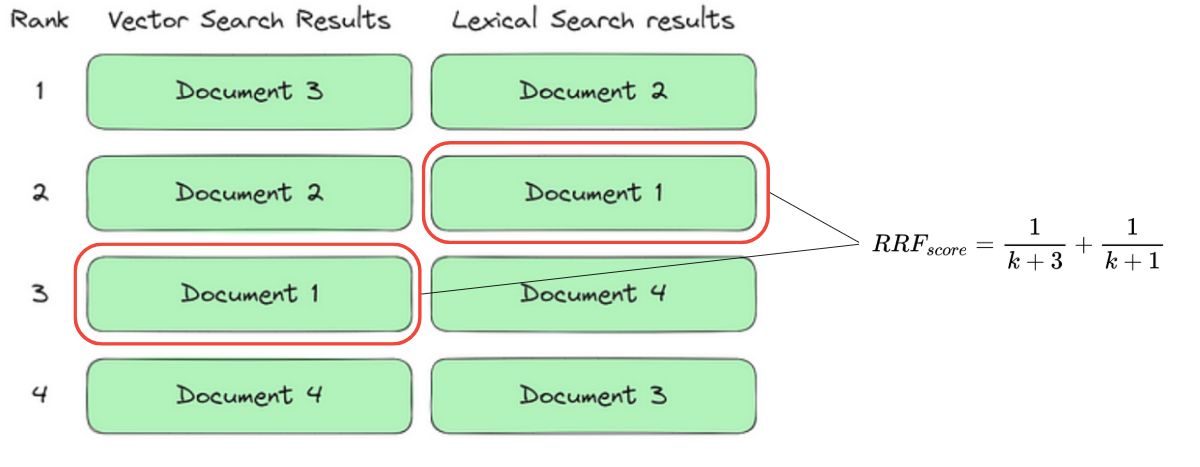
</div>

In [ ]:
def rrf_search(query, top_k):
    fusion_k = 60
    sparse_run = sparse_search(query, top_k)
    dense_run = dense_search_rerank(query, top_k)

    # map scores to ranks (absolute retrieval order)
    sparse_retrieval = {doc: rank for rank, doc in enumerate(sparse_run.keys(), start=1)}
    dense_retrieval = {doc: rank for rank, doc in enumerate(dense_run.keys(), start=1)}

    # do RRF (fuse ranks)
    fused_run = {}
    for ranking in [sparse_retrieval, dense_retrieval]:
        for doc_id, rank in ranking.items():
            if doc_id not in fused_run:
                fused_run[doc_id] = 0
            fused_run[doc_id] += 1 / (fusion_k + rank)

    # get top_k of fused documents with highest scores
    fused_run = dict(list(sorted(fused_run.items(), key=lambda el: -el[1]))[:top_k])
    return fused_run

Let's evaluate our dataset on RRF:

In [ ]:
# do search
with Timer("RRF Full Search"):
    runs = search(queries, rrf_search, top_k)

# evaluate
evals = evaluate(runs, qrels, top_k)
print({metric : f"{value :.3f}" for metric, value in evals.items()}, '\n')

Compare to the best previous case with dense retrieval and re-ranking:

`{'nDCG@15': '0.612', 'R@15': '0.697', 'P@15': '0.053'} `

RRF has higher `Recall` with slightly lower `nDCG`. In production having high `Recall` is often more important, since it allows to get rid of wast majority of irrelevant documents in huge databases.

## [Supplement material] Sentence-Transformer Fine-Tuning

In this section we are going to inspect how we could train a BERT model for semantic search: just like SBERT did!


HF Tutorial: https://huggingface.co/blog/train-sentence-transformers?utm_source=chatgpt.com

Losses supported in Sentence-Trasformers: https://sbert.net/docs/sentence_transformer/loss_overview.html

The page defines different loss functions with specification of input samples formats.

In [ ]:
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments
)
from sentence_transformers.losses import SoftmaxLoss, MultipleNegativesRankingLoss
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator, SimilarityFunction
from sentence_transformers.training_args import BatchSamplers
from datasets import load_dataset, Dataset
import datasets
import random

### Load Evaluation Dataset

Load the Semantic Text Similarity Benchmark (STSB): https://huggingface.co/datasets/nyu-mll/glue/viewer/stsb/validation?views%5B%5D=stsb_validation

It contains text pairs with similarity scores.

We will evaluate two finetuned models on the same dataset for sentence embeddings evaluation.

In [ ]:
eval_dataset = load_dataset("glue", "stsb", split="validation")
eval_dataset = eval_dataset.remove_columns('idx')

# initialize evaluator
dev_evaluator = EmbeddingSimilarityEvaluator(
    sentences1=eval_dataset["sentence1"],
    sentences2=eval_dataset["sentence2"],
    scores=[score / 5 for score in eval_dataset["label"]],
    main_similarity=SimilarityFunction.COSINE,
)

In [ ]:
eval_dataset

In [ ]:
eval_dataset[3]

### Fine-tune S-T with Softmax Loss
https://sbert.net/docs/package_reference/sentence_transformer/losses.html#softmaxloss

#### Prepare Finetuning Dataset


Datset: https://huggingface.co/datasets/stanfordnlp/snli

This is Natural Language Inference (NLI) dataset containing relationship between two sentences:
- Entailment
- Contradiction
- Neutral

In [ ]:
mnli = datasets.load_dataset('glue', 'mnli', split='train')
mnli = mnli.filter(lambda ex: ex["label"] != -1)
mnli = mnli.select(range(50_000))
mnli = mnli.remove_columns('idx')
print(mnli['label'].features.names)
mnli

In [ ]:
mnli[2]

Convert dataset into (sentence1, sentence2, label) triplets with similarity 1 for entailment and 0 for neutral and contradiction

In [ ]:
mapping = {
    0: 1,  # entailment
    1: 0,  # neutral
    2: 0   # contradiction
}

train_dataset = mnli.map(lambda ex: {
    "sentence1": ex["premise"],
    "sentence2": ex["hypothesis"],
    "label": float(ex["label"])
    })
train_dataset = train_dataset.remove_columns(["premise", "hypothesis"])
train_dataset

#### Fine-tune

In [ ]:
base_model = SentenceTransformer('distilbert/distilroberta-base')

# define the loss function
softmax_loss = SoftmaxLoss(
    model=base_model,
    sentence_embedding_dimension=base_model.get_sentence_embedding_dimension(),
    num_labels=3
)

# set training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="base_embedding_model",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    fp16=True,          # Set to False if your GPU can't handle FP16
    bf16=False,
    eval_steps=100,
    logging_steps=100,
    report_to="none",   # disable wandb
)

# set trainer
trainer = SentenceTransformerTrainer(
    model=base_model,
    args=args,
    train_dataset=train_dataset,
    loss=softmax_loss,
    evaluator=dev_evaluator,
)

# train
trainer.train()

In [ ]:
dev_evaluator(base_model)

### Fine-Tune S-T with Multiple Negatives Ranking Loss
https://sbert.net/docs/package_reference/sentence_transformer/losses.html#cosinesimilarityloss

Fine-Tune on triplet loss with contrastive samples (anchor, positive, negative). Negative examples are sampled randomly from the corpus.

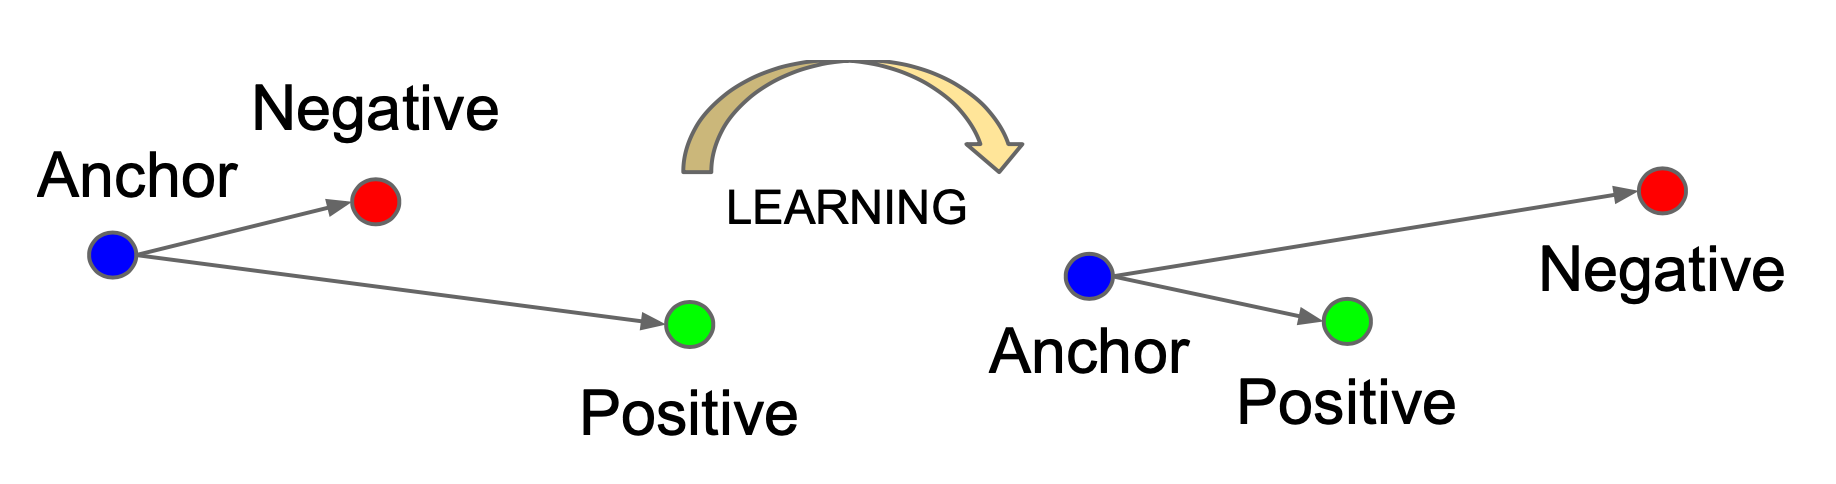

#### Prepare Triplet Dataset

In [ ]:
# select only "entailment" samples qith 0 labels
mnli = datasets.load_dataset('glue', 'mnli', split='train')
mnli = mnli.filter(lambda ex: ex["label"] == 0)
mnli = mnli.select(range(50_000))

# create triplet samples with soft negatives
train_dataset = {"anchor": [], "positive": [], "negative": []}
soft_negatives = list(mnli["hypothesis"])
random.shuffle(soft_negatives)
for row, soft_negative in zip(mnli, soft_negatives):
    train_dataset["anchor"].append(row["premise"])
    train_dataset["positive"].append(row["hypothesis"])
    train_dataset["negative"].append(soft_negative)
train_dataset = Dataset.from_dict(train_dataset)
train_dataset

In [ ]:
train_dataset[1]

#### Fine-tune

In [ ]:
base_model = SentenceTransformer('distilbert/distilroberta-base')

# define the loss function
mnrl_loss = MultipleNegativesRankingLoss(model=base_model)

# set training arguments
args = SentenceTransformerTrainingArguments(
    output_dir="base_embedding_model_mnrl",
    batch_sampler=BatchSamplers.NO_DUPLICATES,  # no duplicate samples in a batch
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    fp16=True,                 # Set to False if your GPU can't handle FP16
    bf16=False,
    eval_steps=100,
    logging_steps=100,
    report_to="none",          # disable wandb
)

# set trainer
trainer = SentenceTransformerTrainer(
    model=base_model,
    args=args,
    train_dataset=train_dataset,
    loss=mnrl_loss,
    evaluator=dev_evaluator,
)

# train
trainer.train()

In [ ]:
dev_evaluator(base_model)

Check this post if you are curious about MNR https://huggingface.co/blog/dragonkue/mitigating-false-negatives-in-retriever-training